<a href="https://www.kaggle.com/code/ranimbenamara/image-denoising?scriptVersionId=314382999" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Deliverable 2 – Image Processing

## TouNum Project – Image Denoising with Convolutional Autoencoders

### Objective

TouNum digitizes large volumes of documents and photographs. Because scanning is performed industrially, image quality can vary due to noise, compression, lighting issues, and acquisition artifacts.

The goal of this deliverable is to build a **pre-processing module** that improves RGB image quality before the images are used by Machine Learning algorithms such as binary classification and image captioning.

This notebook implements a **convolutional denoising autoencoder** trained to remove noise from RGB images.


## Why do we add noise before denoising?

A denoising autoencoder needs paired examples:

| Input | Target |
|---|---|
| noisy image | clean original image |

In real projects, datasets often contain only clean images, without a noisy version of the same image. To solve this, we artificially add controlled noise to the clean images during training.

The learning objective becomes:

```text
Clean RGB Image → Add artificial noise → Autoencoder → Reconstructed clean image
```

This teaches the model to remove noise while preserving the important visual structure of the image.

In TouNum’s context, this simulates scanner noise and prepares the model for real industrial digitization conditions.


## 1. Import libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio

from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Add, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


2026-04-25 15:15:49.602234: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777130149.796622      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777130149.854110      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777130150.329993      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777130150.330031      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777130150.330033      23 computation_placer.cc:177] computation placer alr

## 2. Load the RGB image dataset

The local dataset path is already configured below.

Expected format:

```text
/kaggle/input/datasets/ranimbenamara/dataset-livrable-1/Dataset Livrable 1 - Photo
│
├── image_1.jpg
├── image_2.png
├── image_3.jpeg
└── ...
```

The images must be RGB images. The notebook automatically resizes and normalizes them.


In [2]:
DATASET_PATH = r"/kaggle/input/datasets/ranimbenamara/dataset-livrable-1/Dataset Livrable 1 - Photo"

IMG_SIZE = (128, 128)
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")
IMAGE_DTYPE = np.float32

def load_rgb_images(folder_path, img_size=(128, 128)):
    images = []
    filenames = []

    for file in os.listdir(folder_path):
        if file.lower().endswith(VALID_EXTENSIONS):
            path = os.path.join(folder_path, file)
            img = imageio.imread(path)

            if img.ndim == 2:
                img = np.stack([img, img, img], axis=-1)

            if img.shape[-1] == 4:
                img = img[..., :3]

            img = resize(
                img,
                img_size,
                preserve_range=True,
                anti_aliasing=True
            ).astype(IMAGE_DTYPE) / np.float32(255.0)

            images.append(img)
            filenames.append(file)

    images = np.asarray(images, dtype=IMAGE_DTYPE)
    return images, filenames

images, filenames = load_rgb_images(DATASET_PATH, IMG_SIZE)

print("Number of images loaded:", len(images))
print("Image tensor shape:", images.shape)


Number of images loaded: 5338
Image tensor shape: (5338, 128, 128, 3)


## 3. Display sample original images

This step verifies that the dataset has been loaded correctly.


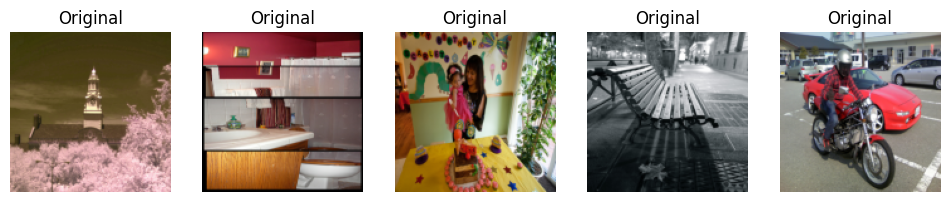

In [3]:
n = min(5, len(images))

plt.figure(figsize=(12, 3))
for i in range(n):
    plt.subplot(1, n, i + 1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis("off")

plt.show()


## 4. Train / test split

The model is trained on one part of the dataset and evaluated on unseen images.


In [4]:
x_train, x_test = train_test_split(
    images,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training set:", x_train.shape)
print("Test set:", x_test.shape)


Training set: (4270, 128, 128, 3)
Test set: (1068, 128, 128, 3)


## 5. Add artificial noise

Gaussian noise is used because it is a common approximation of sensor and scanning noise.

A moderate noise factor is selected to make the task realistic without destroying image details.


In [5]:
def add_gaussian_noise(images, noise_factor=0.06):
    noisy = images + noise_factor * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=images.shape
    ).astype(images.dtype)
    return np.clip(noisy, 0.0, 1.0)

noise_factor = 0.06
BATCH_SIZE = 8

def make_denoising_dataset(clean_images, noise_factor=0.06, batch_size=8, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(clean_images)
    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(clean_images), 256),
            seed=42,
            reshuffle_each_iteration=True
        )

    def _add_noise(image):
        noise = noise_factor * tf.random.normal(tf.shape(image), dtype=image.dtype)
        noisy = tf.clip_by_value(image + noise, 0.0, 1.0)
        return noisy, image

    return (
        dataset
        .map(_add_noise, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

def make_noisy_input_dataset(clean_images, noise_factor=0.06, batch_size=8):
    dataset = tf.data.Dataset.from_tensor_slices(clean_images)

    def _add_noise(image):
        noise = noise_factor * tf.random.normal(tf.shape(image), dtype=image.dtype)
        return tf.clip_by_value(image + noise, 0.0, 1.0)

    return (
        dataset
        .map(_add_noise, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )



## 6. Compare clean and noisy images

This confirms that the model input is degraded while the target remains the original clean image.


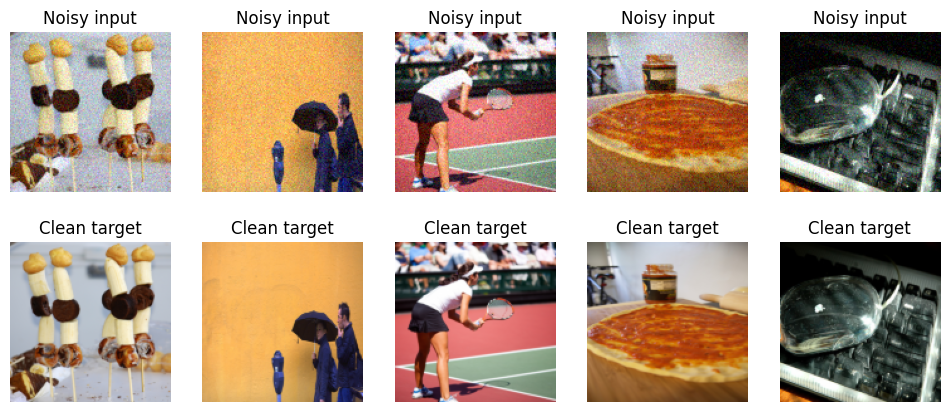

In [6]:
n = min(5, len(x_test))
x_test_noisy_preview = add_gaussian_noise(x_test[:n], noise_factor)

plt.figure(figsize=(12, 5))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy_preview[i])
    plt.title("Noisy input")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_test[i])
    plt.title("Clean target")
    plt.axis("off")

plt.show()


## 7. Build the convolutional denoising autoencoder

This model uses a **residual learning strategy**.

Instead of forcing the network to recreate the whole image from scratch, the model learns a correction that is added to the noisy input. This helps preserve sharp details better than an aggressively compressed encoder-decoder architecture.

This design is used to reduce excessive blur.


In [7]:
input_img = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = BatchNormalization()(x)

x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)

x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = BatchNormalization()(x)

correction = Conv2D(3, (3, 3), activation="linear", padding="same")(x)

output_img = Add()([input_img, correction])
output_img = Activation("sigmoid")(output_img)

autoencoder = Model(input_img, output_img)

autoencoder.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="mse"
)

autoencoder.summary()


I0000 00:00:1777130390.650618      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777130390.656625      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │        867 │ batch_normalizat… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ input_layer[0][0… │
│                     │ 3)                │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,643 (80.64 KB)

 Trainable params: 20,451 (79.89 KB)

 Non-trainable params: 192 (768.00 B)

## 8. Train the denoising model

The model receives noisy images as input and learns to reconstruct the clean originals.


In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

train_ds = make_denoising_dataset(
    x_train,
    noise_factor=noise_factor,
    batch_size=BATCH_SIZE,
    training=True
)

val_ds = make_denoising_dataset(
    x_test,
    noise_factor=noise_factor,
    batch_size=BATCH_SIZE,
    training=False
)

history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)


Epoch 1/50


I0000 00:00:1777130398.293531      75 service.cc:152] XLA service 0x7a35e8004460 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777130398.293576      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777130398.293580      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777130398.775666      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-25 15:20:00.671657: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 15:20:00.955525: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 14/534 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.0922

I0000 00:00:1777130402.769255      75 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


532/534 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0190

2026-04-25 15:20:10.524623: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 15:20:10.808811: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


534/534 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - loss: 0.0189 - val_loss: 0.0044
Epoch 2/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.0035 - val_loss: 0.0015
Epoch 3/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 4/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 0.0025 - val_loss: 0.0014
Epoch 5/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0024 - val_loss: 0.0020
Epoch 6/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0022 - val_loss: 0.0018
Epoch 7/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0021 - val_loss: 0.0013
Epoch 8/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0020 - val_loss: 0.0014
Epoch 9/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0018 - val_loss: 0.0015
Epoch 10/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 11/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.0018 - val_loss: 0.0010
Epoch 12/50
534/534 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/st

## 9. Plot training performance

The validation loss shows whether the model generalizes to unseen images.


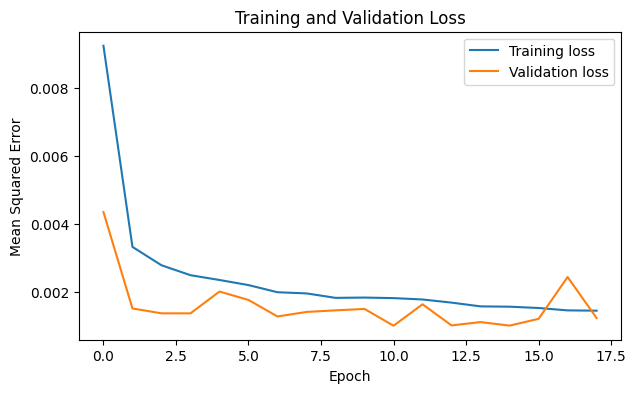

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


## 10. Apply denoising on the test set

In [10]:
denoised_images = autoencoder.predict(
    make_noisy_input_dataset(
        x_test,
        noise_factor=noise_factor,
        batch_size=BATCH_SIZE
    )
 )
denoised_images = np.clip(denoised_images, 0.0, 1.0)


134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


## 11. Visual case study

The following comparison shows:

1. the noisy input image,
2. the denoised image produced by the autoencoder,
3. the original clean image used as ground truth.

The objective is not to create a sharper image than the original. The objective is to recover an image closer to the original and more suitable for downstream Machine Learning.


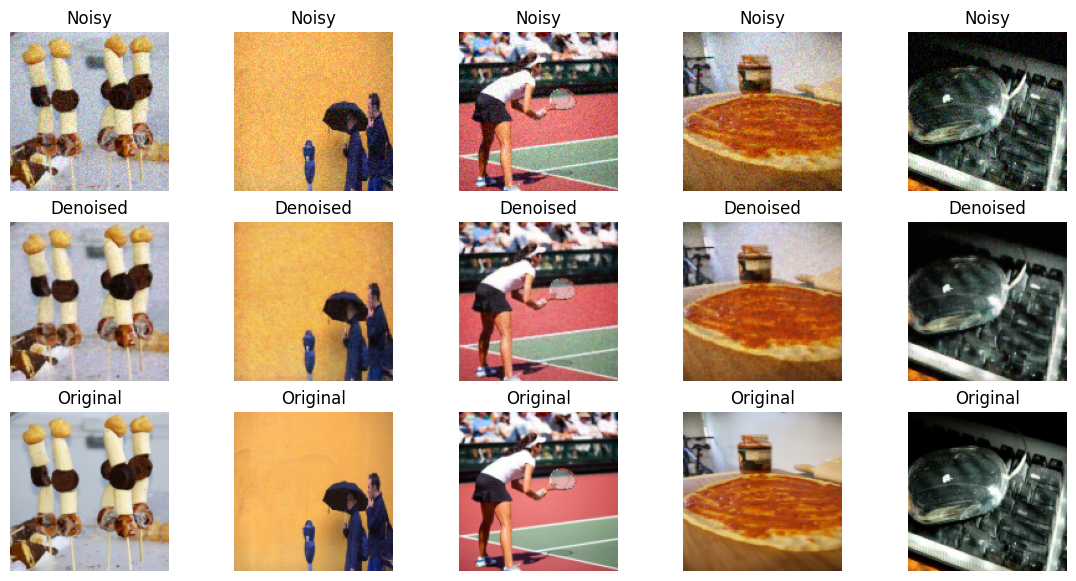

In [11]:
n = min(5, len(x_test))
x_test_noisy_preview = add_gaussian_noise(x_test[:n], noise_factor)

plt.figure(figsize=(14, 7))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy_preview[i])
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i])
    plt.title("Denoised")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

plt.show()


## 12. Quantitative evaluation

Mean Squared Error is used to compare:

- noisy image vs original image
- denoised image vs original image

A successful denoising model should reduce the error.


In [12]:
mse_noisy_values = []
for clean_batch in tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE):
    noisy_batch = tf.clip_by_value(
        clean_batch + noise_factor * tf.random.normal(tf.shape(clean_batch), dtype=clean_batch.dtype),
        0.0,
        1.0
    )
    mse_noisy_values.append(tf.reduce_mean(tf.square(clean_batch - noisy_batch)).numpy())

mse_noisy = float(np.mean(mse_noisy_values))
mse_denoised = float(autoencoder.evaluate(val_ds, verbose=0))

improvement = (mse_noisy - mse_denoised) / mse_noisy * 100

print("MSE - Noisy vs Original:", mse_noisy)
print("MSE - Denoised vs Original:", mse_denoised)
print("Improvement (%):", improvement)


MSE - Noisy vs Original: 0.0033839212264865637
MSE - Denoised vs Original: 0.0010174807393923402
Improvement (%): 69.93190233187657


## 13. Interpretation

If the denoised MSE is lower than the noisy MSE, the model has successfully learned to reduce noise.

Some smoothing can still appear because denoising models remove high-frequency variations. However, the residual architecture used here helps preserve more detail than a heavily compressed autoencoder.

For TouNum, this preprocessing step is valuable because cleaner images improve the reliability of later stages such as image classification and captioning.


## 14. How to reuse this notebook with another local dataset

To apply the same process to another dataset:

1. Put all RGB images in one folder.
2. Replace the path in this cell:

```python
DATASET_PATH = r"/kaggle/input/datasets/ranimbenamara/dataset-livrable-1/Dataset Livrable 1 - Photo"
```

For example:

```python
DATASET_PATH = r"/kaggle/input/datasets/ranimbenamara/dataset-livrable-1/Dataset Livrable 1 - Photo"
```

3. Run all cells again.

No other change is required if the images are `.jpg`, `.jpeg`, or `.png`.


## 15. Save the denoising model

The trained autoencoder is saved with the same artifact name used by the final pipeline so it can be loaded directly for inference.

In [13]:
import os

MODEL_OUTPUT_DIR = "/kaggle/working"
MODEL_PATH = os.path.join(MODEL_OUTPUT_DIR, "deliverable2_denoiser_model.keras")
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

autoencoder.save(MODEL_PATH)
print("Saved denoising model to:", MODEL_PATH)


Saved denoising model to: /kaggle/working/deliverable2_denoiser_model.keras


## Conclusion

This deliverable implemented an automated RGB image denoising pipeline using a convolutional autoencoder.

The workflow includes:

- loading RGB images,
- adding controlled artificial noise,
- training a denoising neural network,
- reconstructing cleaner images,
- evaluating performance visually and quantitatively.

This module fits directly into TouNum’s full Machine Learning workflow as an image quality improvement step before binary classification and image captioning.
